## Working with GARS in Vgrid DGGS

[![image](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/opengeoshub/vgrid/blob/main/docs/notebooks/18_gars.ipynb)
[![image](https://mybinder.org/badge_logo.svg)](https://mybinder.org/v2/gh/opengeoshub/vgrid/HEAD?filepath=docs/notebooks/18_gars.ipynb)
[![image](https://studiolab.sagemaker.aws/studiolab.svg)](https://studiolab.sagemaker.aws/import/github/opengeoshub/vgrid/blob/main/docs/notebooks/18_gars.ipynb)
[![image](https://jupyterlite.rtfd.io/en/latest/_static/badge.svg)](https://demo.gishub.vn/lab/index.html?path=notebooks/vgrid/18_gars.ipynb)

Full Vgrid DGGS documentation is available at [vgrid document](https://vgrid.gishub.vn).

To work with Vgrid DGGS directly in GeoPandas and Pandas, please use [vgridpandas](https://pypi.org/project/vgridpandas/). Full Vgridpandas DGGS documentation is available at [vgridpandas document](https://vgridpandas.gishub.vn).

To work with Vgrid DGGS in QGIS, install the [Vgrid Plugin](https://plugins.qgis.org/plugins/vgridtools/).

To visualize DGGS in Maplibre GL JS, try the [vgrid-maplibre](https://www.npmjs.com/package/vgrid-maplibre) library.

For an interactive demo, visit the [Vgrid Homepage](https://vgrid.vn).

### Install vgrid
Uncomment the following line to install [vgrid](https://pypi.org/project/vgrid/).

In [1]:
# %pip install vgrid --upgrade

### latlon2gars

In [2]:
from vgrid.conversion.latlon2dggs import latlon2gars

lat = 10.775276
lon = 106.706797
res = 3
gars_id = latlon2gars(lat, lon, res)
gars_id

'574JK19'

### GARS to Polygon

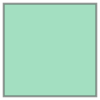

In [3]:
from vgrid.conversion.dggs2geo.gars2geo import gars2geo

gars_geo = gars2geo(gars_id)
gars_geo

### GARS to GeoJSON        

In [ ]:
from vgrid.conversion.dggs2geo.gars2geo import gars2geojson

gars_geojson = gars2geojson(gars_id)
# gars_geojson

### Vector to GARS

d:\Github\vgrid\.venv\Lib\site-packages\pyogrio\raw.py:198: RuntimeWarning: driver GeoJSON does not support open option COMPACT
  return ogr_read(
Processing features: 100%|██████████| 1/1 [00:00<00:00, 266.58it/s]


<Axes: >

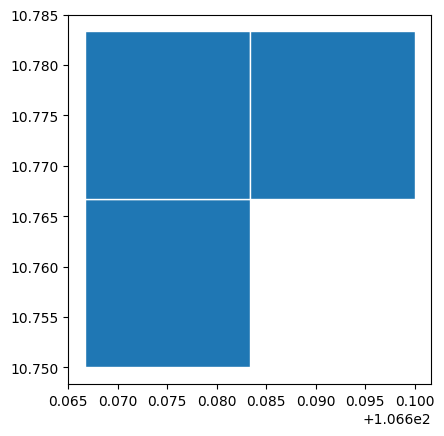

In [5]:
from vgrid.conversion.vector2dggs.vector2gars import vector2gars

file_path = "https://raw.githubusercontent.com/opengeoshub/vopendata/main/shape/polygon2.geojson"
vector_to_gars = vector2gars(
    file_path,
    resolution=4,
    compact=False,
    topology=False,
    predicate="intersects",
    output_format="gpd",
)
# Visualize the output
# vector_to_georef
vector_to_gars.plot(edgecolor="white")

### GARS Binning

Generating GARS DGGS: 100%|██████████| 1558/1558 [00:00<00:00, 4715.50 cells/s]


<Axes: >

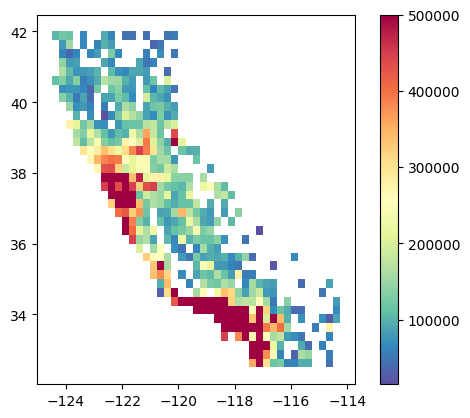

In [2]:
from vgrid.binning.garsbin import garsbin

file_path = (
    "https://raw.githubusercontent.com/opengeoshub/vopendata/main/csv/housing.csv"
)
stats = "max"
gars_bin = garsbin(
    file_path,
    resolution=2,
    stats=stats,
    numeric_col="median_house_value",
    # category_col="category",
    output_format="gpd",
)
gars_bin.plot(
    column=stats,  # numeric column to base the colors on
    cmap="Spectral_r",  # color scheme (matplotlib colormap)
    legend=True,
    linewidth=0.2,  # boundary width (optional)
)

### Raster to GARS

#### Download and open raster

rgb.tif already exists. Skip downloading. Set overwrite=True to overwrite.
{'driver': 'GTiff', 'dtype': 'uint8', 'nodata': None, 'width': 240, 'height': 147, 'count': 3, 'crs': CRS.from_wkt('GEOGCS["WGS 84",DATUM["WGS_1984",SPHEROID["WGS 84",6378137,298.257223563,AUTHORITY["EPSG","7030"]],AUTHORITY["EPSG","6326"]],PRIMEM["Greenwich",0,AUTHORITY["EPSG","8901"]],UNIT["degree",0.0174532925199433,AUTHORITY["EPSG","9122"]],AXIS["Latitude",NORTH],AXIS["Longitude",EAST],AUTHORITY["EPSG","4326"]]'), 'transform': Affine(2.6640125000199077e-06, 0.0, 106.708118755,
       0.0, -2.6640136054383103e-06, 10.812568272)}


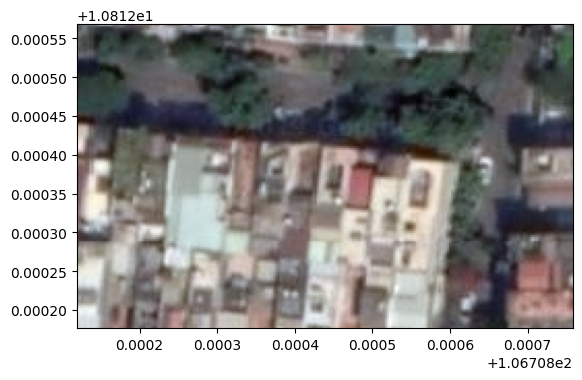

<Axes: >

In [3]:
from vgrid.utils.io import download_file
import rasterio
from rasterio.plot import show

raster_url = (
    "https://raw.githubusercontent.com/opengeoshub/vopendata/main/raster/rgb.tif"
)
raster_file = download_file(raster_url)
src = rasterio.open(raster_file, "r")
print(src.meta)
show(src)

#### Convert raster to GARS


In [ ]:
# %pip install folium

In [4]:
from vgrid.conversion.raster2dggs.raster2gars import raster2gars

raster_to_gars = raster2gars(raster_file, resolution = 1, stats = 'mean', output_format="gpd")

# Visualize the output
import folium

m = folium.Map(tiles="CartoDB positron", max_zoom=28)

gars_layer = folium.GeoJson(
    raster_to_gars,
    style_function=lambda x: {
        "fillColor": f"rgb({x['properties']['band_1']}, {x['properties']['band_2']}, {x['properties']['band_3']})",
        "fillOpacity": 1,
        "color": "black",
        "weight": 1,
    },
    popup=folium.GeoJsonPopup(
        fields=["gars", "band_1", "band_2", "band_3"],
        aliases=["GARS ID", "Band 1", "Band 2", "Band 3"],
        style="""
            background-color: white;
            border: 2px solid black;
            border-radius: 3px;
            box-shadow: 3px;
        """,
    ),
).add_to(m)

m.fit_bounds(gars_layer.get_bounds())

# Display the map
m

Converting raster to GARS: 100%|██████████| 1/1 [00:00<00:00, 246.85 cells/s]


### GARS Generator

In [1]:
from vgrid.generator.garsgrid import garsgrid

gars_grid = garsgrid(
    resolution=4,
    bbox=[106.50410038, 10.68281767, 106.88230310, 10.82281670],
    output_format="geoparquet",
)
# gars_grid.plot(edgecolor="white")

Generating GARS DGGS: 100%|██████████| 207/207 [00:00<00:00, 4712.42 cells/s]

Output file saved as: d:\Github\vgrid\docs\notebooks\gars_grid_4.parquet


### GARS Inspect

In [1]:
from vgrid.stats.garsstats import garsinspect

resolution = 1
gars_inspect = garsinspect(resolution)
gars_inspect.head()

Generating GARS DGGS: 100%|██████████| 259200/259200 [00:29<00:00, 8664.08 cells/s] 


,gars,resolution,center_lat,center_lon,cell_width,cell_height,cell_area,cell_perimeter,geometry,crossed,norm_area,ipq,zsc,cvh
0,001AA,1,-89.75,-179.75,0.000000,55846.975448,1.360844e+07,112181.299964,"POLYGON ((-179.5 -90, -179.5 -89.5, -180 -89.5...",False,0.006915,0.013589,0.116571,1.0
1,001AB,1,-89.25,-179.75,487.349067,55846.889466,4.082421e+07,113155.788271,"POLYGON ((-179.5 -89.5, -179.5 -89, -180 -89, ...",False,0.020746,0.040066,0.200164,1.0
2,001AC,1,-88.75,-179.75,974.660272,55846.717528,6.803661e+07,114129.991081,"POLYGON ((-179.5 -89, -179.5 -88.5, -180 -88.5...",False,0.034574,0.065638,0.256198,1.0
3,001AD,1,-88.25,-179.75,1461.895753,55846.459688,9.524342e+07,115103.832790,"POLYGON ((-179.5 -88.5, -179.5 -88, -180 -88, ...",False,0.048400,0.090337,0.300561,1.0
4,001AE,1,-87.75,-179.75,1949.017659,55846.116027,1.224424e+08,116077.237862,"POLYGON ((-179.5 -88, -179.5 -87.5, -180 -87.5...",False,0.062222,0.114195,0.337928,1.0


### GARS Normalized Area Histogram

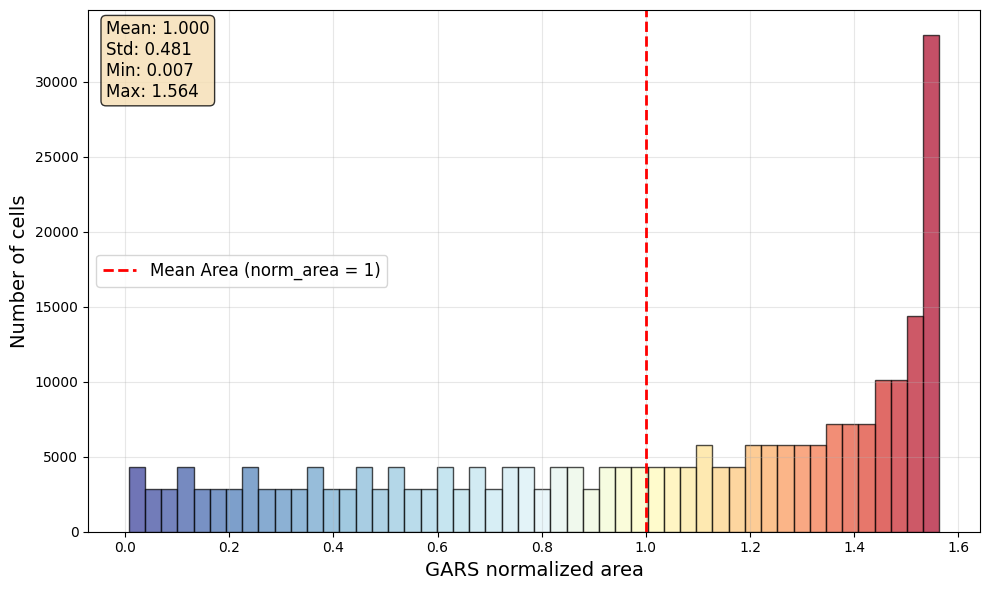

In [2]:
from vgrid.stats.garsstats import gars_norm_area_hist

gars_norm_area_hist(gars_inspect)

### Distribution of GARS Area Distortions

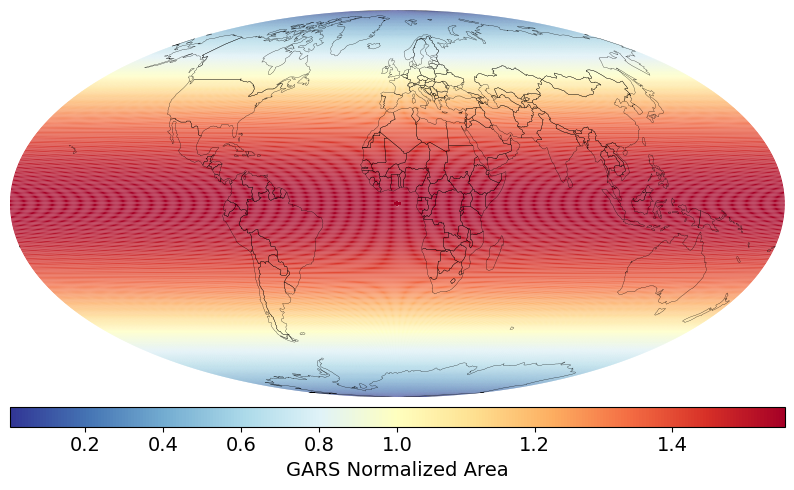

In [3]:
from vgrid.stats.garsstats import gars_norm_area

gars_norm_area(gars_inspect)

### GARS IPQ Compactness Histogram

Isoperimetric Inequality (IPQ) Compactness (suggested by [Osserman, 1978](https://sites.math.washington.edu/~toro/Courses/20-21/MSF/osserman.pdf)):

$$C_{IPQ} = \frac{4 \pi A}{p^2}$$
The range of the IPQ compactness metric is [0,1]. 

A circle represents the maximum compactness with a value of 1. 

As shapes become more irregular or elongated, their compactness decreases toward 0.

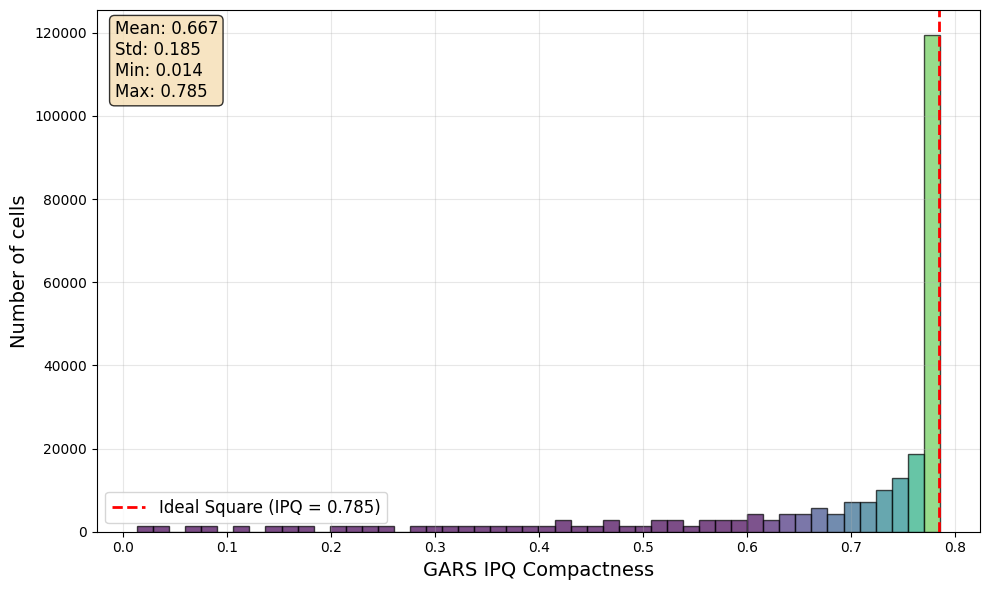

In [4]:
from vgrid.stats.garsstats import gars_compactness_ipq_hist

gars_compactness_ipq_hist(gars_inspect)

### Distribution of GARS IPQ Compactness

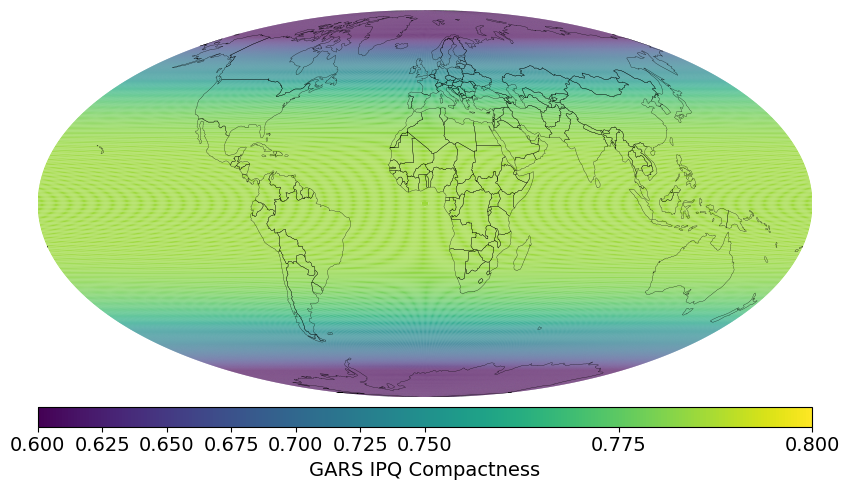

In [5]:
from vgrid.stats.garsstats import gars_compactness_ipq

gars_compactness_ipq(gars_inspect)

### GARS Convex hull Compactness Histogram:

$$C_{CVH} = \frac{A}{A_{CVH}}$$


The range of the convex hull compactness metric is [0,1]. 

As shapes become more concave, their convex hull compactness decreases toward 0.

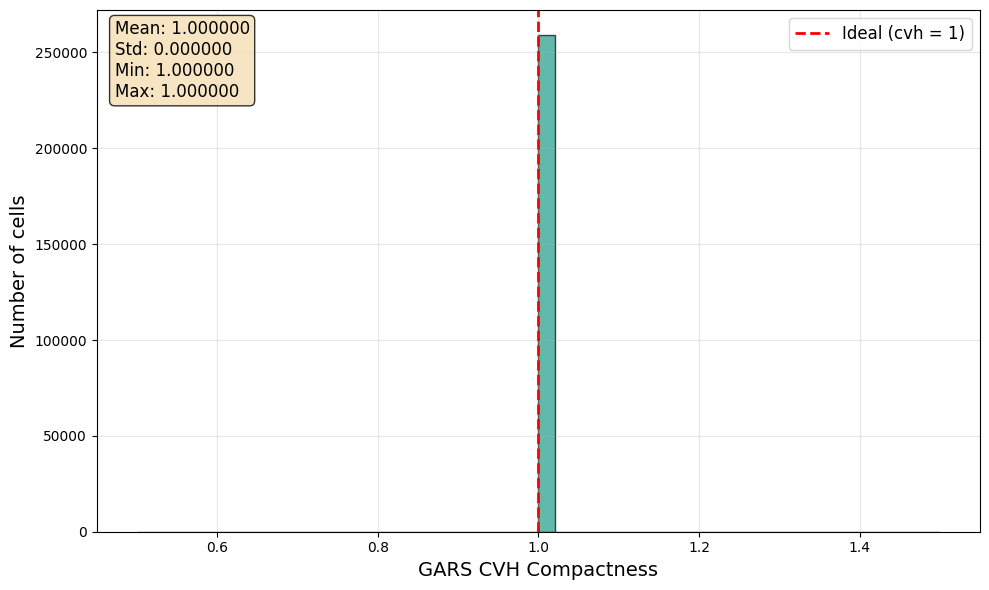

In [6]:
from vgrid.stats.garsstats import gars_compactness_cvh_hist

gars_compactness_cvh_hist(gars_inspect)

### Distribution of GARS Convex hull Compactness

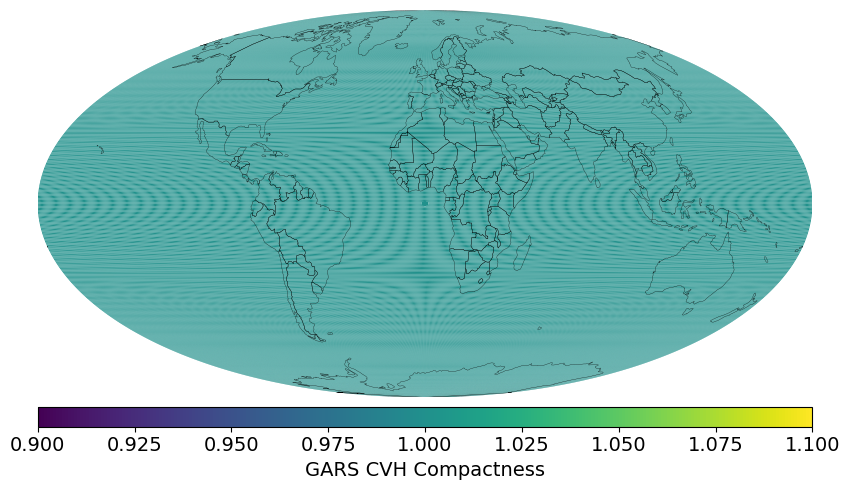

In [7]:
from vgrid.stats.garsstats import gars_compactness_cvh

gars_compactness_cvh(gars_inspect)

### GARS Statistics

Characteristic Length Scale (CLS - suggested by Ralph Kahn): the diameter of a spherical cap of the same cell's area

In [1]:
from vgrid.stats import garsstats

garsstats("km")

,resolution,number_of_cells,avg_edge_len_km,avg_cell_area_km2,cls_km
0,1,259200,44.360408,1967.845763,50.055392
1,2,1036800,22.180204,491.961441,25.027684
2,3,9331200,7.393401,54.662382,8.342560
3,4,233280000,1.478680,2.186495,1.668512


In [3]:
a = 'ABCDEFGHJKLMNPQRSTUVWXYZ'
print(len(a))

24
